In [1]:
import torch
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
from env import mbb
from models import ppo
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import random
from torch import amp
from env import mbb_cnn
from models import ppo_cnn


In [2]:

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set to DEBUG for more detailed logs
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("reward_logs.log"),  # Log to a file
        logging.StreamHandler()  # Also log to console
    ]
)


print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
!nvidia-smi

Fri Mar 28 22:26:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8              4W /   80W |    5150MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
def make_beam_env():
    beam_type = random.choice([1,2,3,4,6,7,8,9])
    # beam_type = random.choice([1,5])
    #beam_type = 1
    return mbb_cnn.BeamOptimizationEnv(width=6, height=6, density=0.4,  optimal_density=0.5, reward_weights=None, beam_type = beam_type)

if __name__ == "__main__":
    # Use spawn for multiprocessing with vectorized envs.
    mp.set_start_method('spawn', force=True)
    
    # Set random seeds for reproducibility.
    random_seed = 0
    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)

    # Hyperparameters.
    env_name = "BeamOptimizationEnv"
    num_envs = 16
    width = 6
    height = 6
    # Your environment returns a 5-channel image of shape (5, width+1, height+1),
    # i.e. (5, 7, 7) so the flattened state has length 5*7*7 = 245.
    grid_channels = 5
    grid_height = width + 1   # 7
    grid_width = height + 1   # 7
    state_dim = grid_channels * grid_height * grid_width  # 245
    action_dim = 2 * width * height  # Discrete actions (72)
    has_continuous_action_space = False
    max_ep_len = width * height * 2
    max_training_timesteps = int(1e5)
    update_timestep = max_ep_len  # Update PPO once per episode.

    # (Continuous action decay parameters, if needed)
    action_std_decay_freq = 5000
    action_std_decay_rate = 0.05
    min_action_std = 0.1

    # Create vectorized environments.
    env_fns = [make_beam_env for _ in range(num_envs)]
    vector_env = AsyncVectorEnv(env_fns)
    print(f"Vector Environment Type: {type(vector_env)}")
    action_dim = vector_env.single_action_space.n
    print(f"Action dimension: {action_dim}")

    # Initialize PPO agent with the CNN-based network.
    ppo_agent = ppo_cnn.PPO(
        state_dim=state_dim,
        action_dim=action_dim,
        lr_actor=0.0003,
        lr_critic=0.001,
        gamma=0.95,
        K_epochs=3,
        eps_clip=0.3,
        has_continuous_action_space=has_continuous_action_space,
        action_std_init=0.6,
        gae_lambda=0.95,
        num_envs=num_envs,
        device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
        grid_channels=grid_channels,
        grid_height=grid_height,
        grid_width=grid_width
    )

    start_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT):", start_time)
    print("=" * 100)

    # Logging and checkpoint setup.
    log_dir = os.path.join("PPO_logs", env_name)
    os.makedirs(log_dir, exist_ok=True)
    run_num = len([name for name in os.listdir(log_dir) if os.path.isfile(os.path.join(log_dir, name))])
    log_f_name = os.path.join(log_dir, f'PPO_{env_name}_log_{run_num}.csv')
    print(f"Current logging run number for {env_name}: {run_num}")
    print(f"Logging at: {log_f_name}")

    checkpoint_dir = os.path.join("PPO_preTrained", env_name)
    os.makedirs(checkpoint_dir, exist_ok=True)
    run_num_pretrained = 0
    checkpoint_path = os.path.join(checkpoint_dir, f"PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth")
    print(f"Save checkpoint path: {checkpoint_path}")

    with open(log_f_name, "w+") as log_f:
        log_f.write("episode,timestep,average_reward\n")

    print_running_reward = 0
    log_running_reward = 0
    print_running_episodes = 0
    log_running_episodes = 0
    timestep = 0
    i_episode = 0

    while timestep < max_training_timesteps:
        # Reset all environments.
        states, infos = vector_env.reset()
        # The environment returns states with shape [num_envs, 5, 7, 7]. Flatten to [num_envs, 245].
        states = torch.tensor(states, dtype=torch.float32, device=ppo_agent.device)
        states = states.view(states.size(0), -1)
        ep_rewards = np.zeros(num_envs)
        
        for t_step in range(1, max_ep_len + 1):
            actions, logprobs, state_values = ppo_agent.select_action(states)
            try:
                next_states, rewards, dones, truncateds, infos = vector_env.step(actions)
            except Exception as e:
                print(f"Error during environment step: {e}")
                break
            dones_combined = np.logical_or(dones, truncateds)
            next_states = torch.tensor(next_states, dtype=torch.float32, device=ppo_agent.device)
            next_states = next_states.view(next_states.size(0), -1)
            if not ppo_agent.has_continuous_action_space:
                actions_tensor = torch.LongTensor(actions).to(ppo_agent.device)
            else:
                actions_tensor = torch.FloatTensor(actions).to(ppo_agent.device)
            ppo_agent.buffer.store(
                states=states,
                actions=actions_tensor,
                logprobs=torch.tensor(logprobs, dtype=torch.float32, device=ppo_agent.device),
                rewards=torch.tensor(rewards, dtype=torch.float32, device=ppo_agent.device),
                state_values=torch.tensor(state_values, dtype=torch.float32, device=ppo_agent.device),
                is_terminals=torch.tensor(dones_combined, dtype=torch.bool, device=ppo_agent.device)
            )
            ep_rewards += rewards
            states = next_states
            timestep += 1

            if timestep % update_timestep == 0:
                ppo_agent.update()

            if ppo_agent.has_continuous_action_space and timestep % action_std_decay_freq == 0:
                ppo_agent.decay_action_std(action_std_decay_rate, min_action_std)

            if timestep % update_timestep == 0:
                avg_reward = log_running_reward / log_running_episodes if log_running_episodes > 0 else 0
                avg_reward = round(np.mean(avg_reward), 4) if isinstance(avg_reward, np.ndarray) else round(avg_reward, 4)
                with open(log_f_name, "a") as log_f:
                    log_f.write(f"{i_episode},{timestep},{avg_reward}\n")
                log_running_reward = 0
                log_running_episodes = 0

            if timestep % (update_timestep * 2) == 0:
                avg_reward = print_running_reward / print_running_episodes if print_running_episodes > 0 else 0
                avg_reward = round(np.mean(avg_reward), 2) if isinstance(avg_reward, np.ndarray) else round(avg_reward, 2)
                print(f"Episode: {i_episode} \t Timestep: {timestep} \t Average Reward: {avg_reward}")
                print_running_reward = 0
                print_running_episodes = 0

            if timestep % 1000 == 0:
                print("-" * 92)
                print(f"Saving model at {checkpoint_path}")
                ppo_agent.save(checkpoint_path)
                print("Model saved.")
                elapsed_time = datetime.now().replace(microsecond=0) - start_time
                print(f"Elapsed Time: {elapsed_time}")
                print("-" * 92)

            if dones_combined.all():
                break

        print_running_reward += ep_rewards.sum()
        print_running_episodes += 1
        log_running_reward += ep_rewards.sum()
        log_running_episodes += 1
        i_episode += 1

    vector_env.close()
    end_time = datetime.now().replace(microsecond=0)
    print("=" * 92)
    print("Started training at (GMT):", start_time)
    print("Finished training at (GMT):", end_time)
    print(f"Total training time: {end_time - start_time}")
    print("=" * 92)
    ppo_agent.plot_metrics()


Vector Environment Type: <class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
Action dimension: 72
Started training at (GMT): 2025-03-28 22:26:49
Current logging run number for BeamOptimizationEnv: 8
Logging at: PPO_logs/BeamOptimizationEnv/PPO_BeamOptimizationEnv_log_8.csv
Save checkpoint path: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth


/home/mihovil/mihovil/structural_optimization/structural_optimization/src/models/ppo_cnn.py:231: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  states = torch.tensor(states, dtype=torch.float32, device=self.device)
/tmp/ipykernel_39989/1955229112.py:118: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logprobs=torch.tensor(logprobs, dtype=torch.float32, device=ppo_agent.device),
/tmp/ipykernel_39989/1955229112.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state_values=torch.tensor(state_values, dtype=torch.float32, device=ppo_agent.d

Episode: 1 	 Timestep: 144 	 Average Reward: -844.49
Episode: 3 	 Timestep: 288 	 Average Reward: -838.78
Episode: 5 	 Timestep: 432 	 Average Reward: -795.38
Episode: 7 	 Timestep: 576 	 Average Reward: -784.06
Episode: 9 	 Timestep: 720 	 Average Reward: -806.53


KeyboardInterrupt: 

In [ ]:
!nvidia-smi

Fri Mar 28 22:20:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P0             17W /   80W |    5524MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

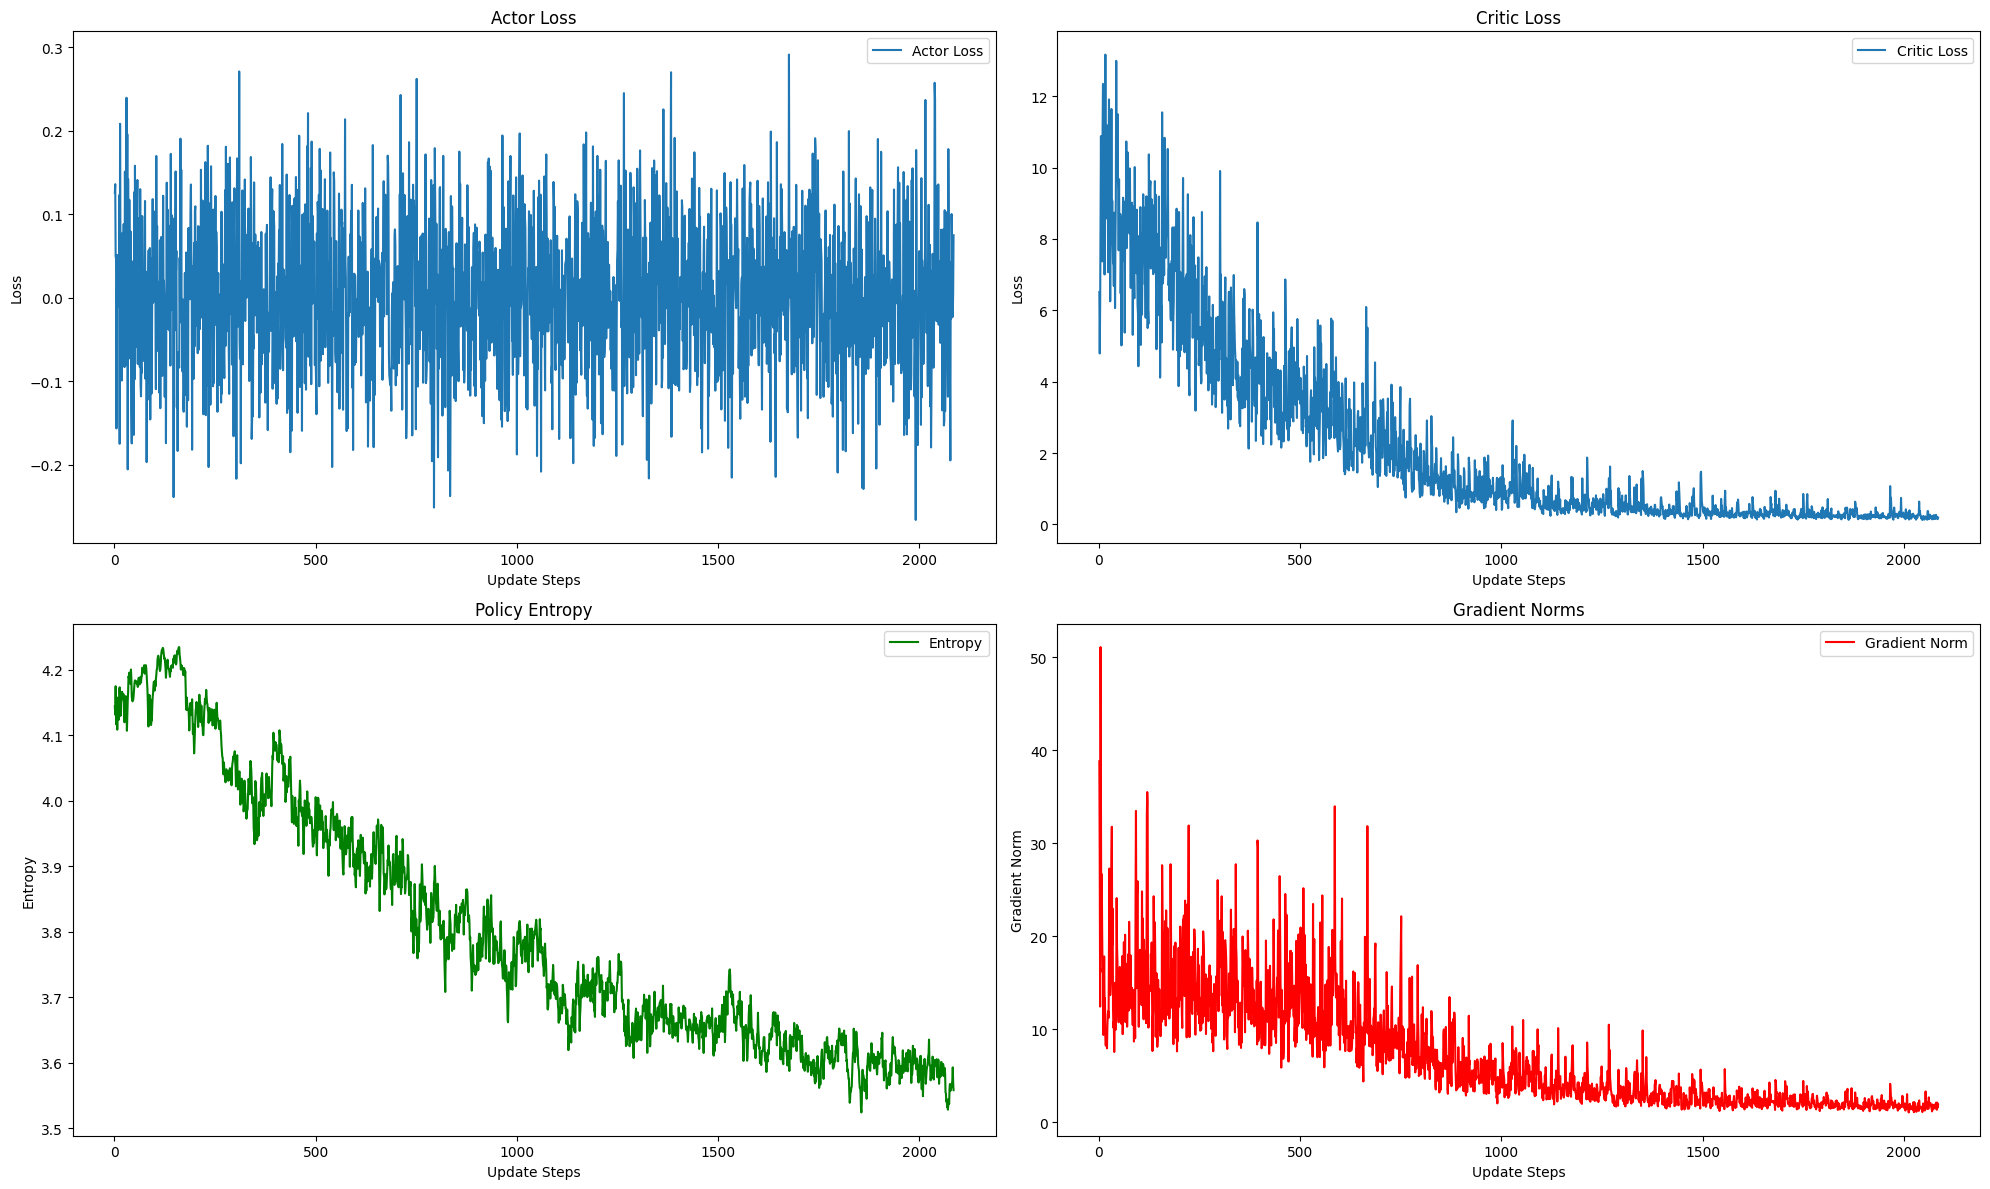

In [ ]:
ppo_agent.plot_metrics()

State dim: 245
Action dim: 72
Loading network from: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
--------------------------------------------------------------------------------------------
Episode 1: Compliance: 28.83047057777247 | Constraint: 0.47931793332099915


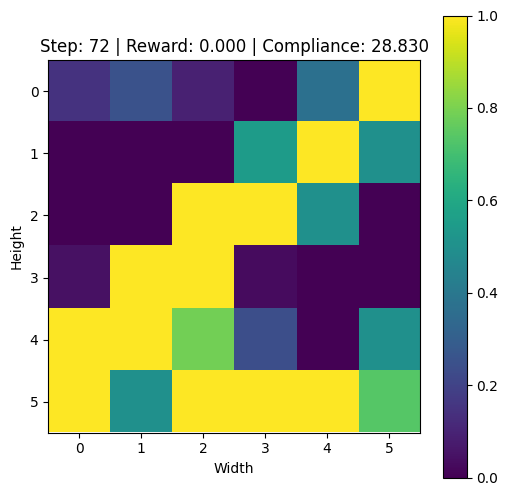

Episode: 1 	 Reward: -23.49
Episode 2: Compliance: 46.1129808917281 | Constraint: 0.47007328271865845


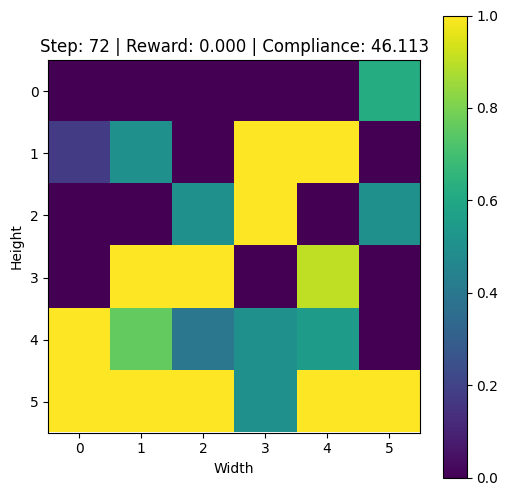

Episode: 2 	 Reward: -25.83
Episode 3: Compliance: 47.378153139116314 | Constraint: 0.4394513666629791


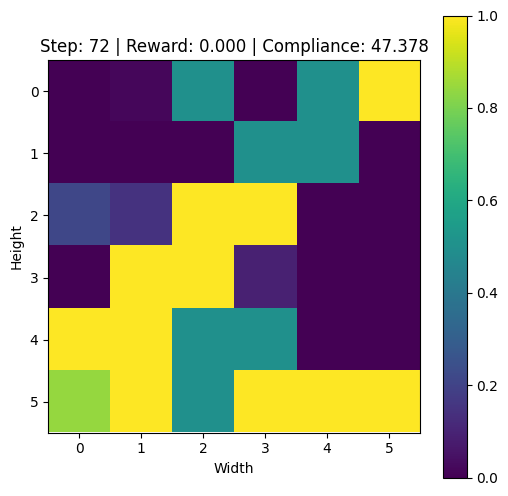

Episode: 3 	 Reward: -25.9
Episode 4: Compliance: 60.2383656373227 | Constraint: 0.43276622891426086


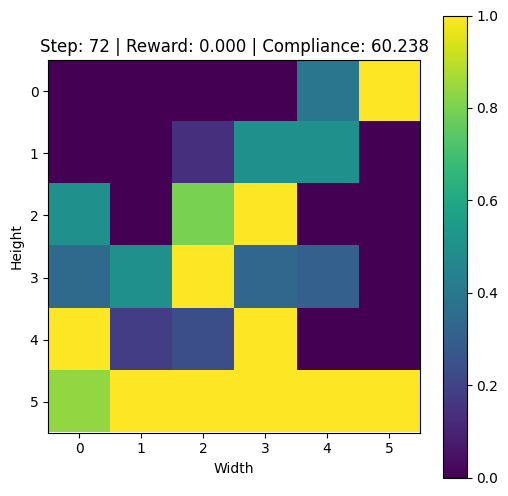

Episode: 4 	 Reward: -28.14
Episode 5: Compliance: 34.29149532931132 | Constraint: 0.4727376401424408


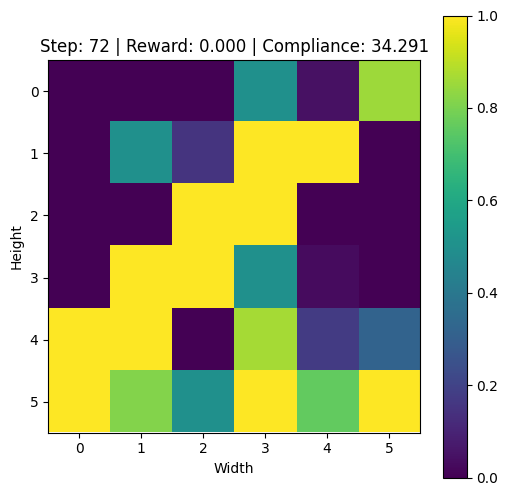

Episode: 5 	 Reward: -25.25
Episode 6: Compliance: 39.40847219229252 | Constraint: 0.4630216062068939


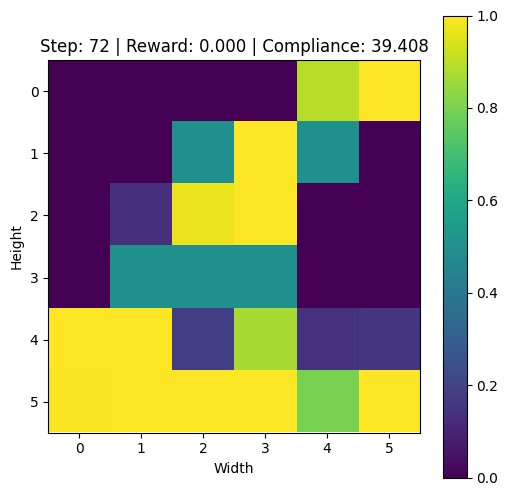

Episode: 6 	 Reward: -25.74
Episode 7: Compliance: 24.572227923637975 | Constraint: 0.47582176327705383


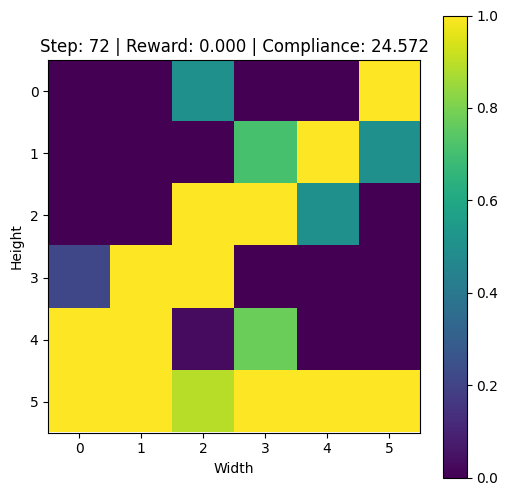

Episode: 7 	 Reward: -21.69
Episode 8: Compliance: 31.29046434589746 | Constraint: 0.48325076699256897


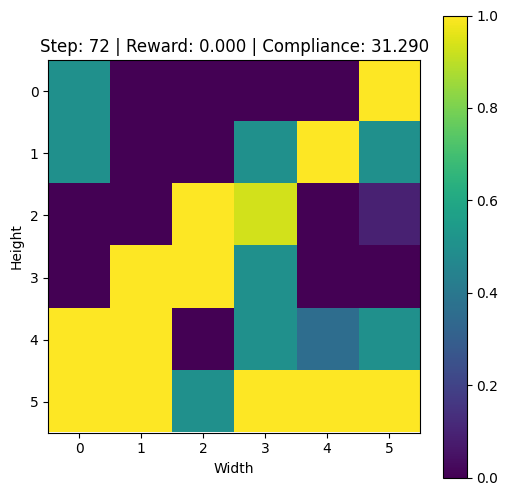

Episode: 8 	 Reward: -25.8
Episode 9: Compliance: 31.625546608420485 | Constraint: 0.4712221920490265


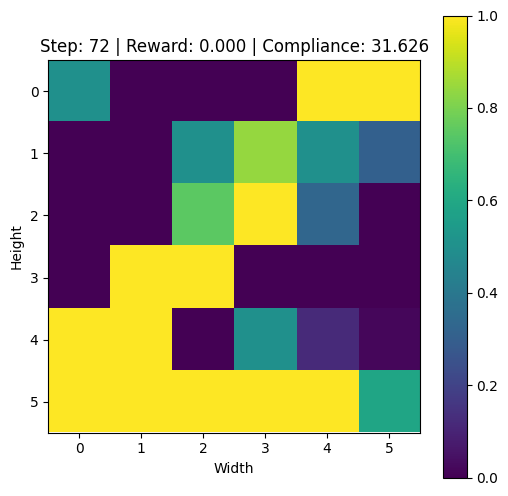

Episode: 9 	 Reward: -23.84
Episode 10: Compliance: 67.92226556591714 | Constraint: 0.4315316379070282


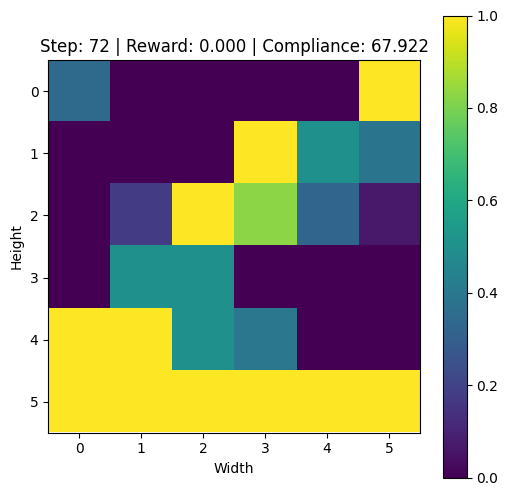

Episode: 10 	 Reward: -27.97
Average test reward: -25.36


In [ ]:
# -------------------------
# Inference Hyperparameters
# -------------------------
env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
total_inference_episodes = 10  # Number of episodes for testing

# (These hyperparameters are only used if you want to re-instantiate the agent.
# They must match those used during training.)
gamma = 0.95
K_epochs = 3
eps_clip = 0.3
lr_actor = 0.0003
lr_critic = 0.001

# Create a single environment instance for testing.
env = mbb_cnn.BeamOptimizationEnv(width=6, height=6, beam_type=5, optimal_density=0.5, density=0.4)
max_ep_len = env.max_steps

# Get the state and action dimensions.
# Our environment returns a 5-channel image of shape (5, 7, 7), so flattened state_dim = 5*7*7 = 245.
state_shape = env.observation_space.shape   # Expected: (5, 7, 7)
state_dim = np.prod(state_shape)              # 245

if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n           # For discrete, e.g., 72
print(f"State dim: {state_dim}")
print(f"Action dim: {action_dim}")

# Set device.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Instantiate the PPO agent.
# For our CNN-based agent, we set grid_channels=5, grid_height=7, grid_width=7.
ppo_agent = ppo_cnn.PPO(
    state_dim=state_dim,
    action_dim=action_dim,
    lr_actor=lr_actor,
    lr_critic=lr_critic,
    gamma=gamma,
    K_epochs=K_epochs,
    eps_clip=eps_clip,
    has_continuous_action_space=has_continuous_action_space,
    action_std_init=0.6,
    gae_lambda=0.95,
    num_envs=1,  # Single environment for inference.
    device=device,
    grid_channels=5,
    grid_height=7,
    grid_width=7
)

# Specify checkpoint path and load weights.
random_seed = 0
run_num_pretrained = 0
checkpoint_path = f"PPO_preTrained/{env_name}/PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth"
print("Loading network from:", checkpoint_path)
ppo_agent.load(checkpoint_path)
print("--------------------------------------------------------------------------------------------")

# -------------------------
# Inference Loop
# -------------------------
test_running_reward = 0.0

for ep in range(1, total_inference_episodes + 1):
    # Reset environment.
    state, _ = env.reset()
    # Flatten the state: original shape is (5, 7, 7) → (245,)
    state_flat = state.flatten()
    ep_reward = 0.0
    for t in range(1, max_ep_len + 1):
        # ppo_agent.select_action expects input shape [batch, state_dim]
        action, _, _ = ppo_agent.select_action(state_flat[None, :])
        # Since the agent returns a batch, take the first element.
        action = action[0]
        state, reward, done, truncated, info = env.step(action)
        ep_reward += reward

        # Flatten new state.
        state_flat = state.flatten()

        if done:
            print(f"Episode {ep}: Compliance: {info['compliance']} | Constraint: {info['constraint']}")
            env.render()  # Render current state.
            break

    test_running_reward += ep_reward
    print(f"Episode: {ep} \t Reward: {round(ep_reward, 2)}")

avg_test_reward = test_running_reward / total_inference_episodes
print("============================================================================================")
print(f"Average test reward: {avg_test_reward:.2f}")
print("============================================================================================")

env.close()
